In [1]:
import os
import json
import pandas as pd

# Carpeta donde están tus JSONs
folder_path = "tracker_tesis/data/trajectories"

# Archivo CSV de salida
output_csv = "trayectorias_completas_street_view.csv"

# Si el archivo ya existe, lo eliminamos para evitar duplicados
if os.path.exists(output_csv):
    os.remove(output_csv)

# Variables de control
batch_size = 100  # Número de archivos por batch
batch_data = []

# Enumerar y procesar por lotes
all_files = [f for f in os.listdir(folder_path) if f.endswith(".json")]

for i, file_name in enumerate(all_files, 1):
    file_path = os.path.join(folder_path, file_name)
    
    try:
        with open(file_path, "r") as f:
            data = json.load(f)

        trajectories = data.get("trajectories", {})
        for track_id, points in trajectories.items():
            for pt in points:
                center = pt.get("center", [None, None])
                batch_data.append({
                    "track_id": track_id,
                    "frame_id": pt.get("frame_id"),
                    "timestamp": pt.get("timestamp"),
                    "cx": center[0],
                    "cy": center[1],
                })

    except Exception as e:
        print(f"⚠️ Error leyendo {file_name}: {e}")

    # Si llegamos al tamaño de batch o es el último archivo, escribimos al CSV
    if i % batch_size == 0 or i == len(all_files):
        df_batch = pd.DataFrame(batch_data)
        # Escribir encabezado solo si es la primera vez
        write_header = not os.path.exists(output_csv)
        df_batch.to_csv(output_csv, mode='a', index=False, header=write_header)
        print(f"✅ Escrito batch hasta archivo {i} ({len(batch_data)} filas)")
        batch_data = []  # Limpiar batch

print("🎉 ¡Procesamiento completo!")

✅ Escrito batch hasta archivo 100 (518203 filas)
✅ Escrito batch hasta archivo 200 (601360 filas)
✅ Escrito batch hasta archivo 300 (572717 filas)
✅ Escrito batch hasta archivo 400 (510869 filas)
✅ Escrito batch hasta archivo 500 (516416 filas)
✅ Escrito batch hasta archivo 600 (541345 filas)
✅ Escrito batch hasta archivo 700 (580677 filas)
✅ Escrito batch hasta archivo 800 (527079 filas)
✅ Escrito batch hasta archivo 900 (566844 filas)
✅ Escrito batch hasta archivo 1000 (511462 filas)
✅ Escrito batch hasta archivo 1100 (560120 filas)
✅ Escrito batch hasta archivo 1200 (578353 filas)
✅ Escrito batch hasta archivo 1300 (523962 filas)
✅ Escrito batch hasta archivo 1400 (503622 filas)
✅ Escrito batch hasta archivo 1500 (533533 filas)
✅ Escrito batch hasta archivo 1600 (548452 filas)
✅ Escrito batch hasta archivo 1700 (531507 filas)
✅ Escrito batch hasta archivo 1800 (530841 filas)
✅ Escrito batch hasta archivo 1900 (547546 filas)
✅ Escrito batch hasta archivo 2000 (578163 filas)
✅ Escrito

In [2]:
df = pd.read_csv("trayectorias_completas_street_view.csv")
df.describe()

,track_id,frame_id,timestamp,cx,cy
count,3.514764e+07,3.514764e+07,3.514764e+07,3.514764e+07,3.514764e+07
mean,4.576973e+03,2.000506e+05,1.761112e+09,9.691283e+02,2.841984e+02
std,2.204289e+03,8.996573e+04,3.353293e+03,3.188905e+02,1.045443e+02
min,1.000000e+00,5.230000e+02,1.761105e+09,1.027223e+01,7.087417e+01
25%,2.898000e+03,1.253040e+05,1.761109e+09,7.439810e+02,2.133270e+02
50%,4.924000e+03,2.152890e+05,1.761113e+09,9.419921e+02,2.570826e+02
75%,6.519000e+03,2.808050e+05,1.761115e+09,1.174031e+03,3.244624e+02
max,7.609000e+03,3.244890e+05,1.761117e+09,1.912388e+03,1.056853e+03


In [3]:
df.dtypes

track_id       int64
frame_id       int64
timestamp    float64
cx           float64
cy           float64
dtype: object

In [4]:
count_df = df[['track_id', 'cx', 'cy']].groupby('track_id').count()

In [5]:
count_df.describe()

,cx,cy
count,6379.000000,6379.000000
mean,5509.897319,5509.897319
std,25021.742715,25021.742715
min,1.000000,1.000000
25%,18.000000,18.000000
50%,178.000000,178.000000
75%,1985.500000,1985.500000
max,789220.000000,789220.000000


In [6]:
df['cx_shifted'] = df.groupby('track_id')['cx'].shift(10)
df['cy_shifted'] = df.groupby('track_id')['cy'].shift(10)  

In [7]:
df_37 = df[df['track_id'] == '37']
df_70 = df[df['track_id'] == '70']

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt 

In [9]:
from scipy.signal import savgol_filter

# Define the window size and polynomial order
window_size = 21  # Must be odd, calculated as 2 * 10 + 1
poly_order = 2    # Polynomial order for the Savitzky-Golay filter

# Calculate the first derivatives (deltas) deterministically
df['x_delta'] = df['cx'] - df['cx_shifted']
df['y_delta'] = df['cy'] - df['cy_shifted']

# Calculate deterministic distance
df['distance'] = (df['x_delta']**2 + df['y_delta']**2)**0.5

# Calculate deterministic velocities and their magnitude
df['x_velocity'] = df['x_delta'] / 10
df['y_velocity'] = df['y_delta'] / 10
df['velocity_magnitude'] = (df['x_velocity']**2 + df['y_velocity']**2)**0.5

# Apply Savitzky-Golay filter for the first derivatives
df['x_delta_savgol'] = savgol_filter(df['cx'], window_size, poly_order, deriv=1)
df['y_delta_savgol'] = savgol_filter(df['cy'], window_size, poly_order, deriv=1)

# Calculate the distance (Euclidean norm of the first derivatives)
df['distance_savgol'] = (df['x_delta_savgol']**2 + df['y_delta_savgol']**2)**0.5

# Apply Savitzky-Golay filter for the second derivatives (velocity)
df['x_velocity_savgol'] = savgol_filter(df['cx'], window_size, poly_order, deriv=2)
df['y_velocity_savgol'] = savgol_filter(df['cy'], window_size, poly_order, deriv=2)

Text(0.5, 1.0, 'Histogram of x Delta')

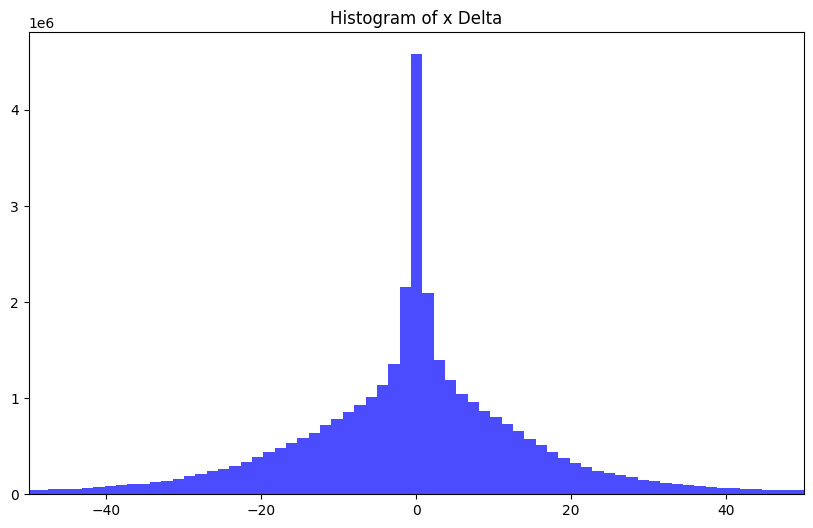

In [10]:
plt.figure(figsize=(10, 6))
plt.hist(df['x_delta'].dropna(), color='blue', alpha=0.7, bins=2000)
plt.xlim(-50, 50)
plt.title('Histogram of x Delta')

Text(0.5, 1.0, 'Histogram of x Delta savgol')

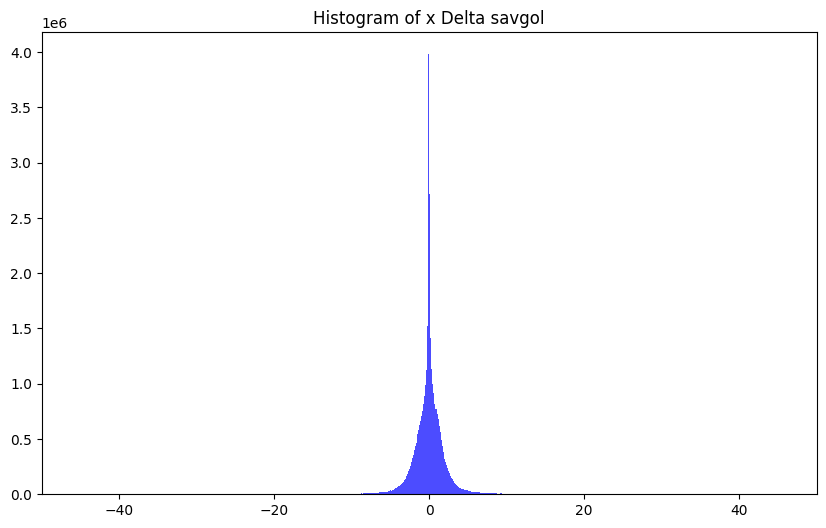

In [11]:
plt.figure(figsize=(10, 6))
plt.hist(df['x_delta_savgol'].dropna(), color='blue', alpha=0.7, bins=2000)
plt.xlim(-50, 50)
plt.title('Histogram of x Delta savgol')

Text(0.5, 1.0, 'Histogram of y Delta')

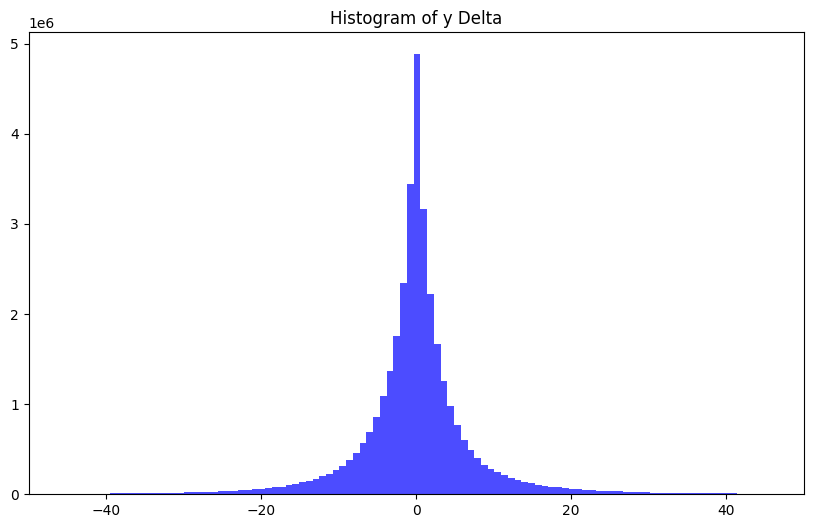

In [12]:
plt.figure(figsize=(10, 6))
plt.hist(df['y_delta'].dropna(), color='blue', alpha=0.7, bins=2000)
plt.xlim(-50, 50)
plt.title('Histogram of y Delta')

Text(0.5, 1.0, 'Histogram of y Delta savgol')

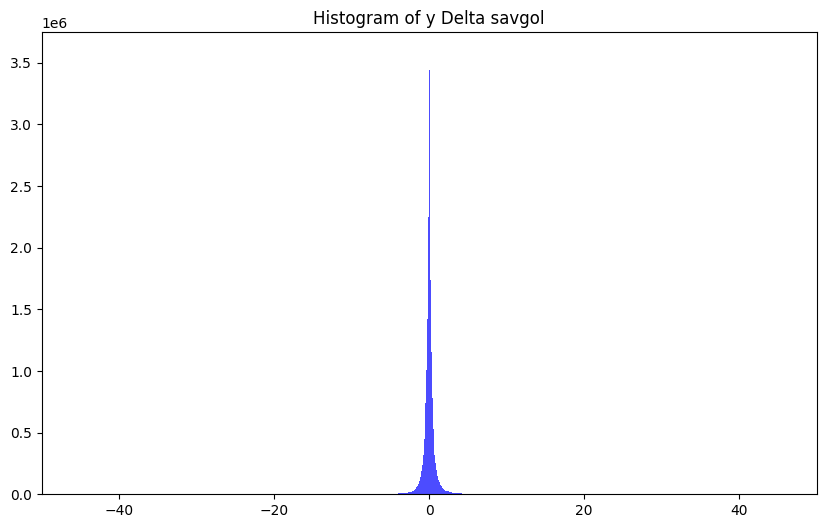

In [13]:
plt.figure(figsize=(10, 6))
plt.hist(df['y_delta_savgol'].dropna(), color='blue', alpha=0.7, bins=2000)
plt.xlim(-50, 50)
plt.title('Histogram of y Delta savgol')

Text(0.5, 1.0, 'Histogram of distance')

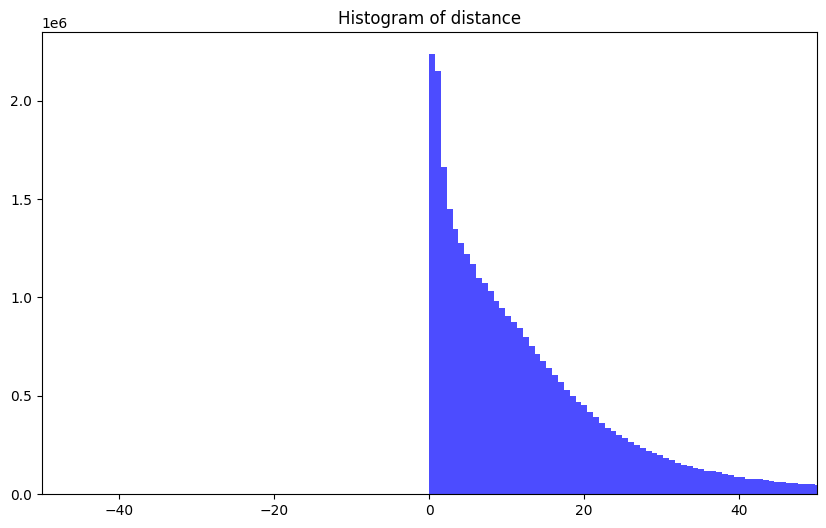

In [14]:
plt.figure(figsize=(10, 6))
plt.hist(df['distance'].dropna(), color='blue', alpha=0.7, bins=2000)
plt.xlim(-50, 50)
plt.title('Histogram of distance')

Text(0.5, 1.0, 'Histogram of velocity')

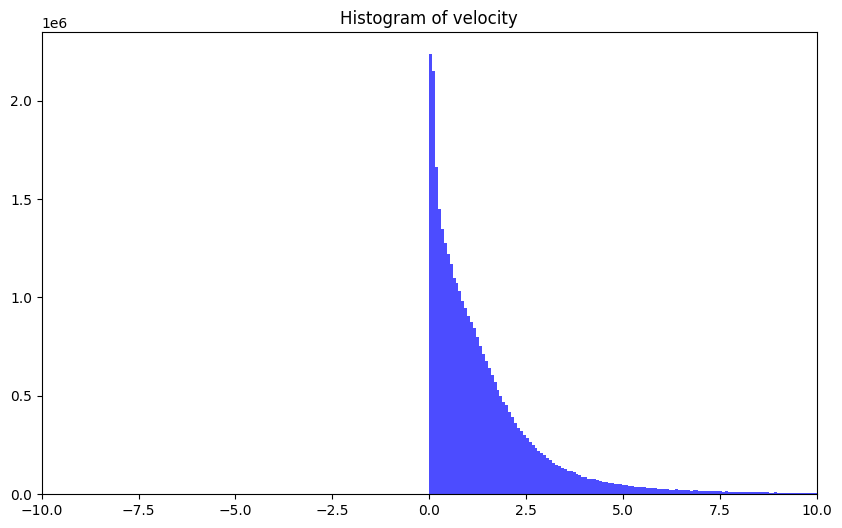

In [15]:
plt.figure(figsize=(10, 6))
plt.hist(df['velocity_magnitude'].dropna(), color='blue', alpha=0.7, bins=2000)
plt.xlim(-10, 10)
plt.title('Histogram of velocity')

In [16]:
# Group by track_id and calculate the required features
features = df.groupby('track_id').agg(
    total_points=('track_id', 'count'),
    x_delta_min=('x_delta', 'min'),
    x_delta_max=('x_delta', 'max'),
    x_delta_avg=('x_delta', 'mean'),
    y_delta_min=('y_delta', 'min'),
    y_delta_max=('y_delta', 'max'),
    y_delta_avg=('y_delta', 'mean'),
    distance_min=('distance', 'min'),
    distance_max=('distance', 'max'),
    distance_avg=('distance', 'mean'),
    velocity_min=('velocity_magnitude', 'min'),
    velocity_max=('velocity_magnitude', 'max'),
    velocity_avg=('velocity_magnitude', 'mean')
).reset_index()

# Display the resulting features dataframe
features.head()

,track_id,total_points,x_delta_min,x_delta_max,x_delta_avg,y_delta_min,y_delta_max,y_delta_avg,distance_min,distance_max,distance_avg,velocity_min,velocity_max,velocity_avg
0,1,182,-50.852102,147.547767,-3.593554,-86.275715,19.537139,2.120182,11.940080,165.932271,43.318169,1.194008,16.593227,4.331817
1,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,806,-22.204739,15.021733,0.016962,-18.184401,37.069290,-0.107181,0.123291,43.186479,7.164143,0.012329,4.318648,0.716414
3,4,2882,-203.243117,37.207167,0.629241,-61.585663,216.544117,-0.617071,0.593438,292.262556,22.498116,0.059344,29.226256,2.249812
4,5,234,-123.494274,35.898555,5.284112,-76.329007,102.281955,-3.232535,1.798277,160.350971,26.100668,0.179828,16.035097,2.610067


In [17]:
!pip install tqdm

In [18]:
import numpy as np
import pandas as pd
import gc
import tqdm

# Definir los bordes de los bins
x_delta_bins = np.concatenate([[-np.inf], np.linspace(-20, 20, 9), [np.inf]])         # 10 bins
y_delta_bins = np.concatenate([[-np.inf], np.linspace(-20, 20, 9), [np.inf]])         # 10 bins
distance_bins = np.concatenate([[0], np.linspace(0.1, 40, 9), [np.inf]])              # evita negativos
velocity_bins = np.concatenate([[0], np.linspace(0.1, 10, 9), [np.inf]])              # desde 0 en adelante

# Función para calcular histogramas por track_id
def compute_histograms(group):
    x_hist = pd.cut(group['x_delta'], bins=x_delta_bins, labels=False)
    y_hist = pd.cut(group['y_delta'], bins=y_delta_bins, labels=False)
    d_hist = pd.cut(group['distance'], bins=distance_bins, labels=False)
    v_hist = pd.cut(group['velocity_magnitude'], bins=velocity_bins, labels=False)

    features = {}
    for i in range(10):
        features[f'x_delta_bin_{i}'] = (x_hist == i).sum()
        features[f'y_delta_bin_{i}'] = (y_hist == i).sum()
        features[f'distance_bin_{i}'] = (d_hist == i).sum()
        features[f'velocity_bin_{i}'] = (v_hist == i).sum()
    return features

# Lista para acumular resultados
hist_rows = []

# Obtener todos los track_ids únicos
track_ids = df['track_id'].unique()
print(f"Procesando {len(track_ids)} track_ids...")

# Loop con barra de progreso
for track_id in tqdm.tqdm(track_ids):
    group = df[df['track_id'] == track_id]
    hist = compute_histograms(group)
    hist['track_id'] = track_id
    hist_rows.append(hist)
    
    del group
    gc.collect()

# Convertir lista a DataFrame
histogram_features = pd.DataFrame(hist_rows)

# Unir con el DataFrame de features existentes
features = pd.merge(features, histogram_features, on='track_id', how='left')

# Mostrar ejemplo
print(features.head())


Procesando 6379 track_ids...


100%|██████████| 6379/6379 [32:06<00:00,  3.31it/s]


   track_id  total_points  x_delta_min  x_delta_max  x_delta_avg  y_delta_min  \
0         1           182   -50.852102   147.547767    -3.593554   -86.275715   
1         2             2          NaN          NaN          NaN          NaN   
2         3           806   -22.204739    15.021733     0.016962   -18.184401   
3         4          2882  -203.243117    37.207167     0.629241   -61.585663   
4         5           234  -123.494274    35.898555     5.284112   -76.329007   

   y_delta_max  y_delta_avg  distance_min  distance_max  ...  distance_bin_7  \
0    19.537139     2.120182     11.940080    165.932271  ...              14   
1          NaN          NaN           NaN           NaN  ...               0   
2    37.069290    -0.107181      0.123291     43.186479  ...               8   
3   216.544117    -0.617071      0.593438    292.262556  ...             132   
4   102.281955    -3.232535      1.798277    160.350971  ...              16   

   velocity_bin_7  x_delta_bin_8

In [19]:
features

,track_id,total_points,x_delta_min,x_delta_max,x_delta_avg,y_delta_min,y_delta_max,y_delta_avg,distance_min,distance_max,...,distance_bin_7,velocity_bin_7,x_delta_bin_8,y_delta_bin_8,distance_bin_8,velocity_bin_8,x_delta_bin_9,y_delta_bin_9,distance_bin_9,velocity_bin_9
0,1,182,-50.852102,147.547767,-3.593554,-86.275715,19.537139,2.120182,11.940080,165.932271,...,14,0,0,73,0,0,20,0,48,20
1,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
2,3,806,-22.204739,15.021733,0.016962,-18.184401,37.069290,-0.107181,0.123291,43.186479,...,8,0,6,7,5,0,0,21,3,0
3,4,2882,-203.243117,37.207167,0.629241,-61.585663,216.544117,-0.617071,0.593438,292.262556,...,132,4,184,139,157,6,445,135,186,90
4,5,234,-123.494274,35.898555,5.284112,-76.329007,102.281955,-3.232535,1.798277,160.350971,...,16,4,31,0,11,0,51,20,25,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6374,7604,38,-3.314011,2.857350,-0.000526,-10.931378,14.995813,3.631898,1.507152,15.008738,...,0,0,0,0,0,0,0,0,0,0
6375,7605,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
6376,7606,27,-4.770013,1.614901,-2.143491,-0.416082,2.837241,1.134754,0.609132,5.027827,...,0,0,0,0,0,0,0,0,0,0
6377,7608,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0


In [20]:
# Exportar a CSV
features.to_csv("features_street_view.csv", index=False)